In [1]:
import numpy as np
import matplotlib.pyplot as plt

See the ATLAS run card: https://github.com/delphes/delphes/blob/master/cards/delphes_card_ATLAS.tcl

## Tracking

In [97]:
#Charged hadron tracking efficiency

# set EfficiencyFormula {                                                    (pt <= 0.1)   * (0.00) +
#                                            (abs(eta) <= 1.5) * (pt > 0.1   && pt <= 1.0)   * (0.70) +
#                                            (abs(eta) <= 1.5) * (pt > 1.0)                  * (0.95) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 0.1   && pt <= 1.0)   * (0.60) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 1.0)                  * (0.85) +
#                          (abs(eta) > 2.5)                                                  * (0.00)}
# }

def EfficiencyFormula_default(pt,eta):
    return (pt <= 0.1) * (0.00) + \
        (abs(eta) <= 1.5) * (pt > 0.1  and pt <= 1.0)   * (0.70) + \
        (abs(eta) <= 1.5) * (pt > 1.0)                  * (0.95) + \
        (abs(eta) > 1.5 and abs(eta) <= 2.5) * (pt > 0.1 and pt <= 1.0) * (0.60) + \
        (abs(eta) > 1.5 and abs(eta) <= 2.5) * (pt > 1.0)               * (0.85) + \
        (abs(eta) > 2.5)                                                * (0.00)

def EfficiencyFormula_new(pt,eta):
    #https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PUBNOTES/ATL-PHYS-PUB-2015-051/, Fig. 1a and 1b (loose)
    #Note, the impact of dense environments is not included here.  For that, see http://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/PERF-2015-08/.

    return ((abs(eta) > 2.5) * 0. + \
        (abs(eta) > 2.40 and abs(eta) <= 2.50) * 0.73+ \
        (abs(eta) > 2.20 and abs(eta) <= 2.40) * 0.79+ \
        (abs(eta) > 2.00 and abs(eta) <= 2.20) * 0.78+ \
        (abs(eta) > 1.80 and abs(eta) <= 2.00) * 0.78+ \
        (abs(eta) > 1.60 and abs(eta) <= 1.80) * 0.80+ \
        (abs(eta) > 1.40 and abs(eta) <= 1.60) * 0.84+ \
        (abs(eta) > 1.20 and abs(eta) <= 1.40) * 0.87+ \
        (abs(eta) > 1.00 and abs(eta) <= 1.20) * 0.88+ \
        (abs(eta) > 0.81 and abs(eta) <= 1.00) * 0.89+ \
        (abs(eta) > 0.60 and abs(eta) <= 0.80) * 0.90+ \
        (abs(eta) > 0.40 and abs(eta) <= 0.60) * 0.91+ \
        (abs(eta) > 0.20 and abs(eta) <= 0.40) * 0.91+ \
        (abs(eta) >= 0.00 and abs(eta) <= 0.20) * 0.91) * \
        ((pt < 0.4) * 0.+ \
        (pt > 0.4 and pt <= 0.55) * 0.78/0.9+ \
        (pt > 0.55 and pt <= 0.65) * 0.84/0.9+ \
        (pt > 0.65 and pt <= 0.75) * 0.85/0.9+ \
        (pt > 0.75 and pt <= 0.85) * 0.86/0.9+ \
        (pt > 0.85 and pt <= 0.95) * 0.86/0.9+ \
        (pt > 0.95 and pt <= 1.05) * 0.86/0.9+ \
        (pt > 1.05 and pt <= 1.15) * 0.87/0.9+ \
        (pt > 1.15 and pt <= 1.25) * 0.87/0.9+ \
        (pt > 1.25 and pt <= 1.35) * 0.87/0.9+ \
        (pt > 1.35 and pt <= 1.45) * 0.87/0.9+ \
        (pt > 1.45 and pt <= 1.75) * 0.88/0.9+ \
        (pt > 1.75 and pt <= 2.25) * 0.88/0.9+ \
        (pt > 2.25 and pt <= 2.75) * 0.88/0.9+ \
        (pt > 2.75 and pt <= 3.25) * 0.89/0.9+ \
        (pt > 3.25 and pt <= 3.75) * 0.89/0.9+ \
        (pt > 3.75 and pt <= 4.5) * 0.89/0.9+ \
        (pt > 4.50) * 0.9/0.9)

def EfficiencyFormula_systup(pt,eta):
    #https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PUBNOTES/ATL-PHYS-PUB-2015-051/, Fig. 1a and 1b (loose)
    #Note, the impact of dense environments is not included here.  For that, see http://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/PERF-2015-08/.

    return ((abs(eta) > 2.5) * 0. + \
        (abs(eta) > 2.40 and abs(eta) <= 2.50) * 0.75+ \
        (abs(eta) > 2.20 and abs(eta) <= 2.40) * 0.81+ \
        (abs(eta) > 2.00 and abs(eta) <= 2.20) * 0.80+ \
        (abs(eta) > 1.80 and abs(eta) <= 2.00) * 0.79+ \
        (abs(eta) > 1.60 and abs(eta) <= 1.80) * 0.81+ \
        (abs(eta) > 1.40 and abs(eta) <= 1.60) * 0.85+ \
        (abs(eta) > 1.20 and abs(eta) <= 1.40) * 0.87+ \
        (abs(eta) > 1.00 and abs(eta) <= 1.20) * 0.89+ \
        (abs(eta) > 0.81 and abs(eta) <= 1.00) * 0.90+ \
        (abs(eta) > 0.60 and abs(eta) <= 0.80) * 0.91+ \
        (abs(eta) > 0.40 and abs(eta) <= 0.60) * 0.91+ \
        (abs(eta) > 0.20 and abs(eta) <= 0.40) * 0.91+ \
        (abs(eta) >= 0.00 and abs(eta) <= 0.20) * 0.91) * \
        ((pt < 0.4) * 0.+ \
        (pt > 0.4 and pt <= 0.55) * 0.79/0.91+ \
        (pt > 0.55 and pt <= 0.65) * 0.85/0.91+ \
        (pt > 0.65 and pt <= 0.75) * 0.86/0.91+ \
        (pt > 0.75 and pt <= 0.85) * 0.87/0.91+ \
        (pt > 0.85 and pt <= 0.95) * 0.87/0.91+ \
        (pt > 0.95 and pt <= 1.05) * 0.87/0.91+ \
        (pt > 1.05 and pt <= 1.15) * 0.88/0.91+ \
        (pt > 1.15 and pt <= 1.25) * 0.88/0.91+ \
        (pt > 1.25 and pt <= 1.35) * 0.88/0.91+ \
        (pt > 1.35 and pt <= 1.45) * 0.88/0.91+ \
        (pt > 1.45 and pt <= 1.75) * 0.88/0.91+ \
        (pt > 1.75 and pt <= 2.25) * 0.89/0.91+ \
        (pt > 2.25 and pt <= 2.75) * 0.89/0.91+ \
        (pt > 2.75 and pt <= 3.25) * 0.90/0.91+ \
        (pt > 3.25 and pt <= 3.75) * 0.90/0.91+ \
        (pt > 3.75 and pt <= 4.5) * 0.90/0.91+ \
        (pt > 4.50) * 0.91/0.91)

Text(0, 0.5, 'Track Reconstruction Efficiency')

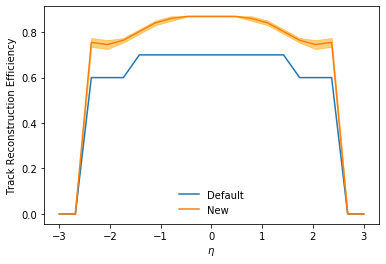

In [98]:
old = np.array([EfficiencyFormula_default(1,x) for x in np.linspace(-3,3,20)])
new = np.array([EfficiencyFormula_new(1,x) for x in np.linspace(-3,3,20)])
new_up = np.array([EfficiencyFormula_systup(1,x) for x in np.linspace(-3,3,20)])
plt.plot(np.linspace(-3,3,20),old,label="Default")
plt.plot(np.linspace(-3,3,20),new,label="New")
plt.fill_between(np.linspace(-3,3,20),new-(new_up-new),new_up,color="orange",alpha=0.5)
plt.legend(frameon=False)
plt.xlabel("$\eta$")
plt.ylabel("Track Reconstruction Efficiency")

Text(0, 0.5, 'Track Reconstruction Efficiency')

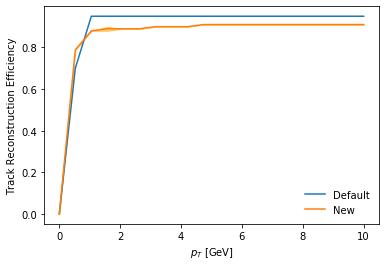

In [99]:
old = np.array([EfficiencyFormula_default(x,0) for x in np.linspace(0,10,20)])
new = np.array([EfficiencyFormula_new(x,0) for x in np.linspace(0,10,20)])
new_up = np.array([EfficiencyFormula_systup(x,0) for x in np.linspace(0,10,20)])
plt.plot(np.linspace(0,10,20),old,label="Default")
plt.plot(np.linspace(0,10,20),new,label="New")
plt.fill_between(np.linspace(0,10,20),new-(new_up-new),new_up,color="orange",alpha=0.5)
plt.legend(frameon=False)
plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Track Reconstruction Efficiency")

In [100]:
# Electron tracking efficiency

#   set EfficiencyFormula {                                                    (pt <= 0.1)   * (0.00) +
#                                            (abs(eta) <= 1.5) * (pt > 0.1   && pt <= 1.0)   * (0.73) +
#                                            (abs(eta) <= 1.5) * (pt > 1.0   && pt <= 1.0e2) * (0.95) +
#                                            (abs(eta) <= 1.5) * (pt > 1.0e2)                * (0.99) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 0.1   && pt <= 1.0)   * (0.50) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 1.0   && pt <= 1.0e2) * (0.83) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 1.0e2)                * (0.90) +
#                          (abs(eta) > 2.5)                                                  * (0.00)}
# }

In [101]:
# Muon tracking efficiency

#   set EfficiencyFormula {                                                    (pt <= 0.1)   * (0.00) +
#                                            (abs(eta) <= 1.5) * (pt > 0.1   && pt <= 1.0)   * (0.75) +
#                                            (abs(eta) <= 1.5) * (pt > 1.0)                  * (0.99) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 0.1   && pt <= 1.0)   * (0.70) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 1.0)                  * (0.98) +
#                          (abs(eta) > 2.5)                                                  * (0.00)}
# }

In [144]:
# Momentum resolution for charged tracks

#   set ResolutionFormula {                  (abs(eta) <= 0.5) * (pt > 0.1) * sqrt(0.06^2 + pt^2*1.3e-3^2) +
#                          (abs(eta) > 0.5 && abs(eta) <= 1.5) * (pt > 0.1) * sqrt(0.10^2 + pt^2*1.7e-3^2) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 0.1) * sqrt(0.25^2 + pt^2*3.1e-3^2)}
# }

def ResolutionFormula_default(pt,eta):
    return (abs(eta) <= 0.5) * (pt > 0.1) * np.sqrt(0.06**2 + pt**2*1.3e-3**2) + \
                         (abs(eta) > 0.5 and abs(eta) <= 1.5) * (pt > 0.1) * np.sqrt(0.10**2 + pt**2*1.7e-3**2) + \
                         (abs(eta) > 1.5 and abs(eta) <= 2.5) * (pt > 0.1) * np.sqrt(0.25**2 + pt**2*3.1e-3**2)

def ResolutionFormula_new(pt,eta):
    #pt dependence from Eq. 2 in https://arxiv.org/pdf/1703.10485.pdf, which comes from Sec. 3.8 (p.95) in https://cds.cern.ch/record/391176/files/cer-0317330.pdf
    #eta dependence + uncert from https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/PERF-2015-10/figaux_11a.png
    return np.sqrt(0.013**2 + 0.00036**2*pt**2) * \
    ((abs(eta) > 2.31) * 4.16/1.73 + \
    (abs(eta) > 1.89 and abs(eta) <= 2.31) * 2.89/1.73 + \
    (abs(eta) > 1.46 and abs(eta) <= 1.89) * 2.18/1.73 + \
    (abs(eta) > 1.05 and abs(eta) <= 1.46) * 1.95/1.73 + \
    (abs(eta) > 0.63 and abs(eta) <= 1.05) * 1.86/1.73 + \
    (abs(eta) >= 0. and abs(eta) <= 0.63) * 1.73/1.73)

def ResolutionFormula_systup(pt,eta):
    #pt dependence from Eq. 2 in https://arxiv.org/pdf/1703.10485.pdf, which comes from Sec. 3.8 (p.95) in https://cds.cern.ch/record/391176/files/cer-0317330.pdf
    #eta dependence + uncert from https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/PERF-2015-10/figaux_11a.png
    return np.sqrt(0.013**2 + 0.00036**2*pt**2) * \
    ((abs(eta) > 2.31) * 1.1*4.16/1.73 + \
    (abs(eta) > 1.89 and abs(eta) <= 2.31) * 1.06*2.89/1.73 + \
    (abs(eta) > 1.46 and abs(eta) <= 1.89) * 1.05*2.18/1.73 + \
    (abs(eta) > 1.05 and abs(eta) <= 1.46) * 1.09*1.95/1.73 + \
    (abs(eta) > 0.63 and abs(eta) <= 1.05) * 1.03*1.86/1.73 + \
    (abs(eta) >= 0. and abs(eta) <= 0.63) * 1.05*1.73/1.73)

Text(0, 0.5, 'Track Momentum Resolution')

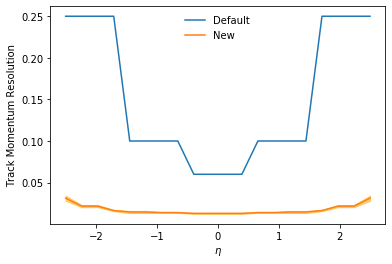

In [153]:
old = np.array([ResolutionFormula_default(1,x) for x in np.linspace(-2.5,2.5,20)])
new = np.array([ResolutionFormula_new(1,x) for x in np.linspace(-2.5,2.5,20)])
new_up = np.array([ResolutionFormula_systup(1,x) for x in np.linspace(-2.5,2.5,20)])
plt.plot(np.linspace(-2.5,2.5,20),old,label="Default")
plt.plot(np.linspace(-2.5,2.5,20),new,label="New")
plt.fill_between(np.linspace(-2.5,2.5,20),new-(new_up-new),new_up,color="orange",alpha=0.5)
plt.legend(frameon=False)
plt.xlabel("$\eta$")
plt.ylabel("Track Momentum Resolution")

Text(0, 0.5, 'Track Momentum Resolution')

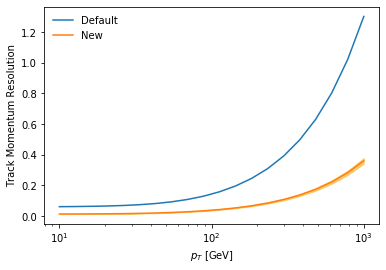

In [154]:
old = np.array([ResolutionFormula_default(x,0) for x in np.logspace(1,3,20)])
new = np.array([ResolutionFormula_new(x,0) for x in np.logspace(1,3,20)])
new_up = np.array([ResolutionFormula_systup(x,0) for x in np.logspace(1,3,20)])
plt.plot(np.logspace(1,3,20),old,label="Default")
plt.plot(np.logspace(1,3,20),new,label="New")
plt.fill_between(np.logspace(1,3,20),new-(new_up-new),new_up,color="orange",alpha=0.5)
plt.legend(frameon=False)
plt.xscale("log")
plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Track Momentum Resolution")

In [103]:
# Momentum resolution for electrons

#   set ResolutionFormula {                  (abs(eta) <= 0.5) * (pt > 0.1) * sqrt(0.03^2 + pt^2*1.3e-3^2) +
#                          (abs(eta) > 0.5 && abs(eta) <= 1.5) * (pt > 0.1) * sqrt(0.05^2 + pt^2*1.7e-3^2) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 0.1) * sqrt(0.15^2 + pt^2*3.1e-3^2)}
# }

In [104]:
# Momentum resolution for muons

#   set ResolutionFormula {                  (abs(eta) <= 0.5) * (pt > 0.1) * sqrt(0.01^2 + pt^2*1.0e-4^2) +
#                          (abs(eta) > 0.5 && abs(eta) <= 1.5) * (pt > 0.1) * sqrt(0.015^2 + pt^2*1.5e-4^2) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 0.1) * sqrt(0.025^2 + pt^2*3.5e-4^2)}
# }

## Calorimetery

In [ ]:
# #############
# #   ECAL
# #############

# module SimpleCalorimeter ECal {
#   set ParticleInputArray ParticlePropagator/stableParticles
#   set TrackInputArray TrackMerger/tracks

#   set TowerOutputArray ecalTowers
#   set EFlowTrackOutputArray eflowTracks
#   set EFlowTowerOutputArray eflowPhotons

#   set IsEcal true

#   set EnergyMin 0.5
#   set EnergySignificanceMin 2.0

#   set SmearTowerCenter true

#   set pi [expr {acos(-1)}]

#   # lists of the edges of each tower in eta and phi
#   # each list starts with the lower edge of the first tower
#   # the list ends with the higher edged of the last tower

#   # assume 0.02 x 0.02 resolution in eta,phi in the barrel |eta| < 1.5

#   set PhiBins {}
#   for {set i -180} {$i <= 180} {incr i} {
#     add PhiBins [expr {$i * $pi/180.0}]
#   }

#   # 0.02 unit in eta up to eta = 1.5 (barrel)
#   for {set i -85} {$i <= 86} {incr i} {
#     set eta [expr {$i * 0.0174}]
#     add EtaPhiBins $eta $PhiBins
#   }

#   # assume 0.02 x 0.02 resolution in eta,phi in the endcaps 1.5 < |eta| < 3.0
#   set PhiBins {}
#   for {set i -180} {$i <= 180} {incr i} {
#     add PhiBins [expr {$i * $pi/180.0}]
#   }

#   # 0.02 unit in eta up to eta = 3
#   for {set i 1} {$i <= 84} {incr i} {
#     set eta [expr { -2.958 + $i * 0.0174}]
#     add EtaPhiBins $eta $PhiBins
#   }

#   for {set i 1} {$i <= 84} {incr i} {
#     set eta [expr { 1.4964 + $i * 0.0174}]
#     add EtaPhiBins $eta $PhiBins
#   }

#   # take present CMS granularity for HF

#   # 0.175 x (0.175 - 0.35) resolution in eta,phi in the HF 3.0 < |eta| < 5.0
#   set PhiBins {}
#   for {set i -18} {$i <= 18} {incr i} {
#     add PhiBins [expr {$i * $pi/18.0}]
#   }

#   foreach eta {-5 -4.7 -4.525 -4.35 -4.175 -4 -3.825 -3.65 -3.475 -3.3 -3.125 -2.958 3.125 3.3 3.475 3.65 3.825 4 4.175 4.35 4.525 4.7 5} {
#     add EtaPhiBins $eta $PhiBins
#   }


#   add EnergyFraction {0} {0.0}
#   # energy fractions for e, gamma and pi0
#   add EnergyFraction {11} {1.0}
#   add EnergyFraction {22} {1.0}
#   add EnergyFraction {111} {1.0}
#   # energy fractions for muon, neutrinos and neutralinos
#   add EnergyFraction {12} {0.0}
#   add EnergyFraction {13} {0.0}
#   add EnergyFraction {14} {0.0}
#   add EnergyFraction {16} {0.0}
#   add EnergyFraction {1000022} {0.0}
#   add EnergyFraction {1000023} {0.0}
#   add EnergyFraction {1000025} {0.0}
#   add EnergyFraction {1000035} {0.0}
#   add EnergyFraction {1000045} {0.0}
#   # energy fractions for K0short and Lambda
#   add EnergyFraction {310} {0.3}
#   add EnergyFraction {3122} {0.3}

#   # set ResolutionFormula {resolution formula as a function of eta and energy}

#   # set ECalResolutionFormula {resolution formula as a function of eta and energy}
#   # http://arxiv.org/pdf/physics/0608012v1 jinst8_08_s08003
#   # http://villaolmo.mib.infn.it/ICATPP9th_2005/Calorimetry/Schram.p.pdf
#   # http://www.physics.utoronto.ca/~krieger/procs/ComoProceedings.pdf
#   set ResolutionFormula {                      (abs(eta) <= 3.2) * sqrt(energy^2*0.0017^2 + energy*0.101^2) +
#                              (abs(eta) > 3.2 && abs(eta) <= 4.9) * sqrt(energy^2*0.0350^2 + energy*0.285^2)}


# }


# #############
# #   HCAL
# #############

# module SimpleCalorimeter HCal {
#   set ParticleInputArray ParticlePropagator/stableParticles
#   set TrackInputArray ECal/eflowTracks

#   set TowerOutputArray hcalTowers
#   set EFlowTrackOutputArray eflowTracks
#   set EFlowTowerOutputArray eflowNeutralHadrons

#   set IsEcal false

#   set EnergyMin 1.0
#   set EnergySignificanceMin 2.0

#   set SmearTowerCenter true

#  set pi [expr {acos(-1)}]

#   # lists of the edges of each tower in eta and phi
#   # each list starts with the lower edge of the first tower
#   # the list ends with the higher edged of the last tower

#   # 10 degrees towers
#   set PhiBins {}
#   for {set i -18} {$i <= 18} {incr i} {
#     add PhiBins [expr {$i * $pi/18.0}]
#   }
#   foreach eta {-3.2 -2.5 -2.4 -2.3 -2.2 -2.1 -2 -1.9 -1.8 -1.7 -1.6 -1.5 -1.4 -1.3 -1.2 -1.1 -1 -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1 0 0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1 1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2 2.1 2.2 2.3 2.4 2.5 2.6 3.3} {
#     add EtaPhiBins $eta $PhiBins
#   }

#   # 20 degrees towers
#   set PhiBins {}
#   for {set i -9} {$i <= 9} {incr i} {
#     add PhiBins [expr {$i * $pi/9.0}]
#   }
#   foreach eta {-4.9 -4.7 -4.5 -4.3 -4.1 -3.9 -3.7 -3.5 -3.3 -3 -2.8 -2.6 2.8 3 3.2 3.5 3.7 3.9 4.1 4.3 4.5 4.7 4.9} {
#     add EtaPhiBins $eta $PhiBins
#   }

#   # default energy fractions {abs(PDG code)} {Fecal Fhcal}
#   add EnergyFraction {0} {1.0}
#   # energy fractions for e, gamma and pi0
#   add EnergyFraction {11} {0.0}
#   add EnergyFraction {22} {0.0}
#   add EnergyFraction {111} {0.0}
#   # energy fractions for muon, neutrinos and neutralinos
#   add EnergyFraction {12} {0.0}
#   add EnergyFraction {13} {0.0}
#   add EnergyFraction {14} {0.0}
#   add EnergyFraction {16} {0.0}
#   add EnergyFraction {1000022} {0.0}
#   add EnergyFraction {1000023} {0.0}
#   add EnergyFraction {1000025} {0.0}
#   add EnergyFraction {1000035} {0.0}
#   add EnergyFraction {1000045} {0.0}
#   # energy fractions for K0short and Lambda
#   add EnergyFraction {310} {0.7}
#   add EnergyFraction {3122} {0.7}

#   # http://arxiv.org/pdf/hep-ex/0004009v1
#   # http://villaolmo.mib.infn.it/ICATPP9th_2005/Calorimetry/Schram.p.pdf
#   # set HCalResolutionFormula {resolution formula as a function of eta and energy}
#   set ResolutionFormula {                      (abs(eta) <= 1.7) * sqrt(energy^2*0.0302^2 + energy*0.5205^2 + 1.59^2) +
#                              (abs(eta) > 1.7 && abs(eta) <= 3.2) * sqrt(energy^2*0.0500^2 + energy*0.706^2) +
#                              (abs(eta) > 3.2 && abs(eta) <= 4.9) * sqrt(energy^2*0.09420^2 + energy*1.00^2)}
# }

## Lepton and Photon ID

In [ ]:
#Electron efficiency

#   # efficiency formula for electrons
#   set EfficiencyFormula {                                      (pt <= 10.0) * (0.00) +
#                                            (abs(eta) <= 1.5) * (pt > 10.0)  * (0.95) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 10.0)  * (0.85) +
#                          (abs(eta) > 2.5)                                   * (0.00)}
# }

In [ ]:
#Electron isolation

# module Isolation ElectronIsolation {
#   set CandidateInputArray ElectronEfficiency/electrons
#   set IsolationInputArray EFlowFilter/eflow

#   set OutputArray electrons

#   set DeltaRMax 0.5

#   set PTMin 0.5

#   set PTRatioMax 0.12
# }

In [ ]:
#Muon efficiency

#   set EfficiencyFormula {                                      (pt <= 10.0) * (0.00) +
#                                            (abs(eta) <= 1.5) * (pt > 10.0)  * (0.95) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.7) * (pt > 10.0)  * (0.85) +
#                          (abs(eta) > 2.7)                                   * (0.00)}
# }

In [ ]:
#Muon isolation

# module Isolation MuonIsolation {
#   set CandidateInputArray MuonEfficiency/muons
#   set IsolationInputArray EFlowFilter/eflow

#   set OutputArray muons

#   set DeltaRMax 0.5

#   set PTMin 0.5

#   set PTRatioMax 0.25
# }

In [ ]:
#Photon efficiency

#   set EfficiencyFormula {                                      (pt <= 10.0) * (0.00) +
#                                            (abs(eta) <= 1.5) * (pt > 10.0)  * (0.95) +
#                          (abs(eta) > 1.5 && abs(eta) <= 2.5) * (pt > 10.0)  * (0.85) +
#                          (abs(eta) > 2.5)                                   * (0.00)}
# }

In [ ]:
#Photon isolation

# module Isolation PhotonIsolation {
#   set CandidateInputArray PhotonEfficiency/photons
#   set IsolationInputArray EFlowFilter/eflow

#   set OutputArray photons

#   set DeltaRMax 0.5

#   set PTMin 0.5

#   set PTRatioMax 0.12
# }

## Taus

In [ ]:
#   set ParticleInputArray Delphes/allParticles
#   set PartonInputArray Delphes/partons
#   set TrackInputArray TrackMerger/tracks
#   set JetInputArray JetEnergyScale/jets

#   set DeltaR 0.2
#   set DeltaRTrack 0.2

#   set TrackPTMin 1.0

#   set TauPTMin 1.0
#   set TauEtaMax 2.5

#   # instructions: {n-prongs} {eff}

#   # 1 - one prong efficiency
#   # 2 - two or more efficiency
#   # -1 - one prong mistag rate
#   # -2 - two or more mistag rate

#   set BitNumber 0

#   # taken from ATL-PHYS-PUB-2015-045 (medium working point)
#   add EfficiencyFormula {1} {0.70}
#   add EfficiencyFormula {2} {0.60}
#   add EfficiencyFormula {-1} {0.02}
#   add EfficiencyFormula {-2} {0.01}

## Jet Calibration

In [155]:
#Jet energy scale

#   # algorithm: 1 CDFJetClu, 2 MidPoint, 3 SIScone, 4 kt, 5 Cambridge/Aachen, 6 antikt
#   set JetAlgorithm 6
#   set ParameterR 0.6

#   set JetPTMin 20.0

# set ScaleFormula {  sqrt( (3.0 - 0.2*(abs(eta)))^2 / pt + 1.0 )  }

## b-tagging

In [ ]:
#   set DeltaR 0.5
#   set PartonPTMin 1.0
#   set PartonEtaMax 2.5

#   # based on ATL-PHYS-PUB-2015-022

#   # default efficiency formula (misidentification rate)
#   add EfficiencyFormula {0} {0.002+7.3e-06*pt}

#   # efficiency formula for c-jets (misidentification rate)
#   add EfficiencyFormula {4} {0.20*tanh(0.02*pt)*(1/(1+0.0034*pt))}

#   # efficiency formula for b-jets
#   add EfficiencyFormula {5} {0.80*tanh(0.003*pt)*(30/(1+0.086*pt))}